In [45]:
%cd /home/smalani/PartialObservations/
from URPModel import helper
from config import config


/home/smalani/PartialObservations


In [46]:
Case = "Case8b"
config["MODEL"]["BOX"] = 'Grey'
config["MODEL"]["Parameters"] = 'Trainable'
config["DATA"]["N_TRAIN"] = 77

index = 0
filename = "/home/smalani/PartialObservations/data/" + Case + "/model_run_" + str(index) + ".net"

network = helper.load_network(filename)



[0.96053704 4.32732445]
[0.30841537 0.54954638]
/home/smalani/PartialObservations/data/Case8b/model_run_0.net
my_Network(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=3, out_features=64, bias=True)
      (1): Linear(in_features=64, out_features=64, bias=True)
    )
    (activation): SiLU()
    (output_layer): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [47]:
import numpy as np
import torch

def phi_network(x_in_RHS, p_in_RHS):
        return network.raw_output(x_in_RHS, p_in_RHS)

x1_arr = np.linspace(0.5, 0.9, 100)
x2_arr = np.linspace(0.9, 3.5, 100)
Da = 0.44

x1, x2 = np.meshgrid(x1_arr, x2_arr)

x1_flat = torch.from_numpy(x1.flatten())
x2_flat = torch.from_numpy(x2.flatten())

x_torchin = torch.stack((x1_flat, x2_flat), dim=1)
p_torchin = torch.ones(x_torchin.shape[0], 1) * Da

print(x_torchin.shape)
print(p_torchin.shape)

phi_out = phi_network(x_torchin, p_torchin)
print(phi_out.shape)

torch.Size([10000, 2])
torch.Size([10000, 1])
torch.Size([10000, 1])


In [48]:
# import matplotlib.pyplot as plt
# from matplotlib import cm

# phi_out_np = phi_out.detach().numpy()
# phi_out_np = phi_out_np.reshape(x1.shape)

# phi_true = p_torchin.detach().numpy().reshape(x1.shape) * (1-x1) * np.exp(x2)

# fig = plt.figure(figsize=(20, 10))
# ax = plt.subplot(121, projection='3d')
# surf = ax.plot_surface(x1, x2, phi_out_np, cmap=cm.coolwarm,
#                           linewidth=0, antialiased=False)
# ax.set_xlabel('x1')
# ax.set_ylabel('x2')
# ax.set_zlabel('phi')
# ax.set_zlim(0,2)

# ax = plt.subplot(122, projection='3d')
# surf = ax.plot_surface(x1, x2, phi_true, cmap=cm.coolwarm,
#                           linewidth=0, antialiased=False)
# ax.set_xlabel('x1')
# ax.set_ylabel('x2')
# ax.set_zlabel('phi')
# ax.set_zlim(0,2)
# plt.show()

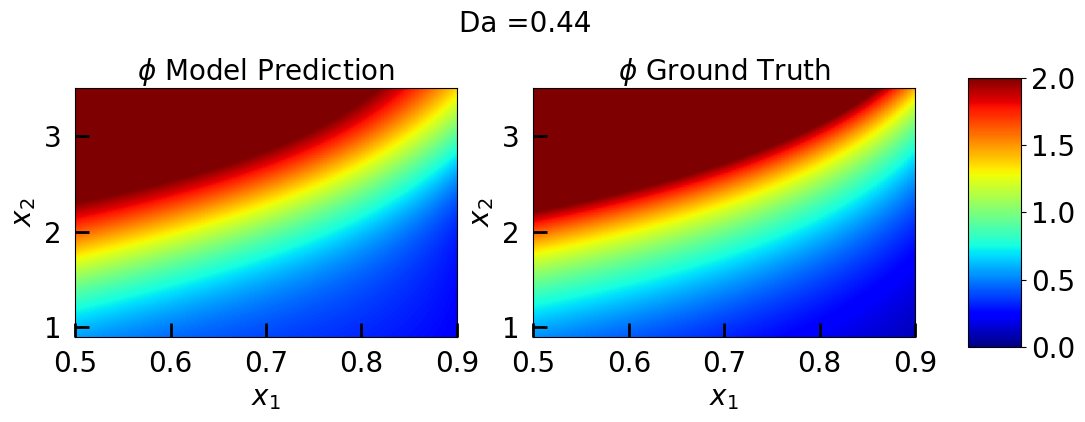

In [49]:
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

phi_out_np = phi_out.detach().numpy()
phi_out_np = phi_out_np.reshape(x1.shape)

phi_true = p_torchin.detach().numpy().reshape(x1.shape) * (1-x1) * np.exp(x2)

fig, axes = plt.subplots(figsize=(12, 5), nrows=1, ncols=2)
ax = axes[0]
surf = ax.imshow(phi_out_np, cmap='jet', vmin=0, vmax=2, extent=[min(x1_arr), max(x1_arr), min(x2_arr), max(x2_arr)],aspect=0.1, origin='lower')
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20, pad=10, length=10, width=2, direction='in')
ax.set_title(r'$\phi$ Model Prediction', fontsize=20)


ax = axes[1]
surf = ax.imshow(phi_true, cmap='jet', vmin=0, vmax=2, extent=[min(x1_arr), max(x1_arr), min(x2_arr), max(x2_arr)],aspect=0.1, origin='lower')
ax.set_xlabel(r'$x_1$', fontsize=20)
ax.set_ylabel(r'$x_2$', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20, pad=10, length=10, width=2, direction='in')
ax.set_title(r'$\phi$ Ground Truth', fontsize=20)

fig.subplots_adjust(right=1)
cbar = plt.colorbar(surf, aspect=5, pad=0.05, ax=axes.ravel().tolist(),shrink=0.7)
cbar.ax.tick_params(labelsize=20)
plt.suptitle('Da =' + str(Da), fontsize=20, y=0.9)
# plt.tight_layout()
plt.show()

In [50]:
import numpy as np
import torch

def phi_network(x_in_RHS, p_in_RHS):
        return network.raw_output(x_in_RHS, p_in_RHS)

x1_arr = np.linspace(0.5, 0.9, 100)
x2_arr = np.linspace(0.9, 3.5, 100)
Da_arr = np.array([0.26,0.33,0.44])
phi_out_arr = np.zeros((Da_arr.shape[0], x1_arr.shape[0], x2_arr.shape[0]))
phi_true_arr = np.zeros((Da_arr.shape[0], x1_arr.shape[0], x2_arr.shape[0]))
phi_error_arr = np.zeros((Da_arr.shape[0], x1_arr.shape[0], x2_arr.shape[0]))

x1, x2 = np.meshgrid(x1_arr, x2_arr)

x1_flat = torch.from_numpy(x1.flatten())
x2_flat = torch.from_numpy(x2.flatten())


for i, Da in enumerate(Da_arr):
    x_torchin = torch.stack((x1_flat, x2_flat), dim=1)
    p_torchin = torch.ones(x_torchin.shape[0], 1) * Da
    phi_out = phi_network(x_torchin, p_torchin)
    phi_out_arr[i,:,:] = phi_out.detach().numpy().reshape(x1.shape)
    phi_true_arr[i,:,:] = p_torchin.detach().numpy().reshape(x1.shape) * (1-x1) * np.exp(x2)
    phi_error_arr[i,:,:] = np.abs(phi_out_arr[i,:,:] - phi_true_arr[i,:,:])


Text(0.05, 0.5, '$x_2$')

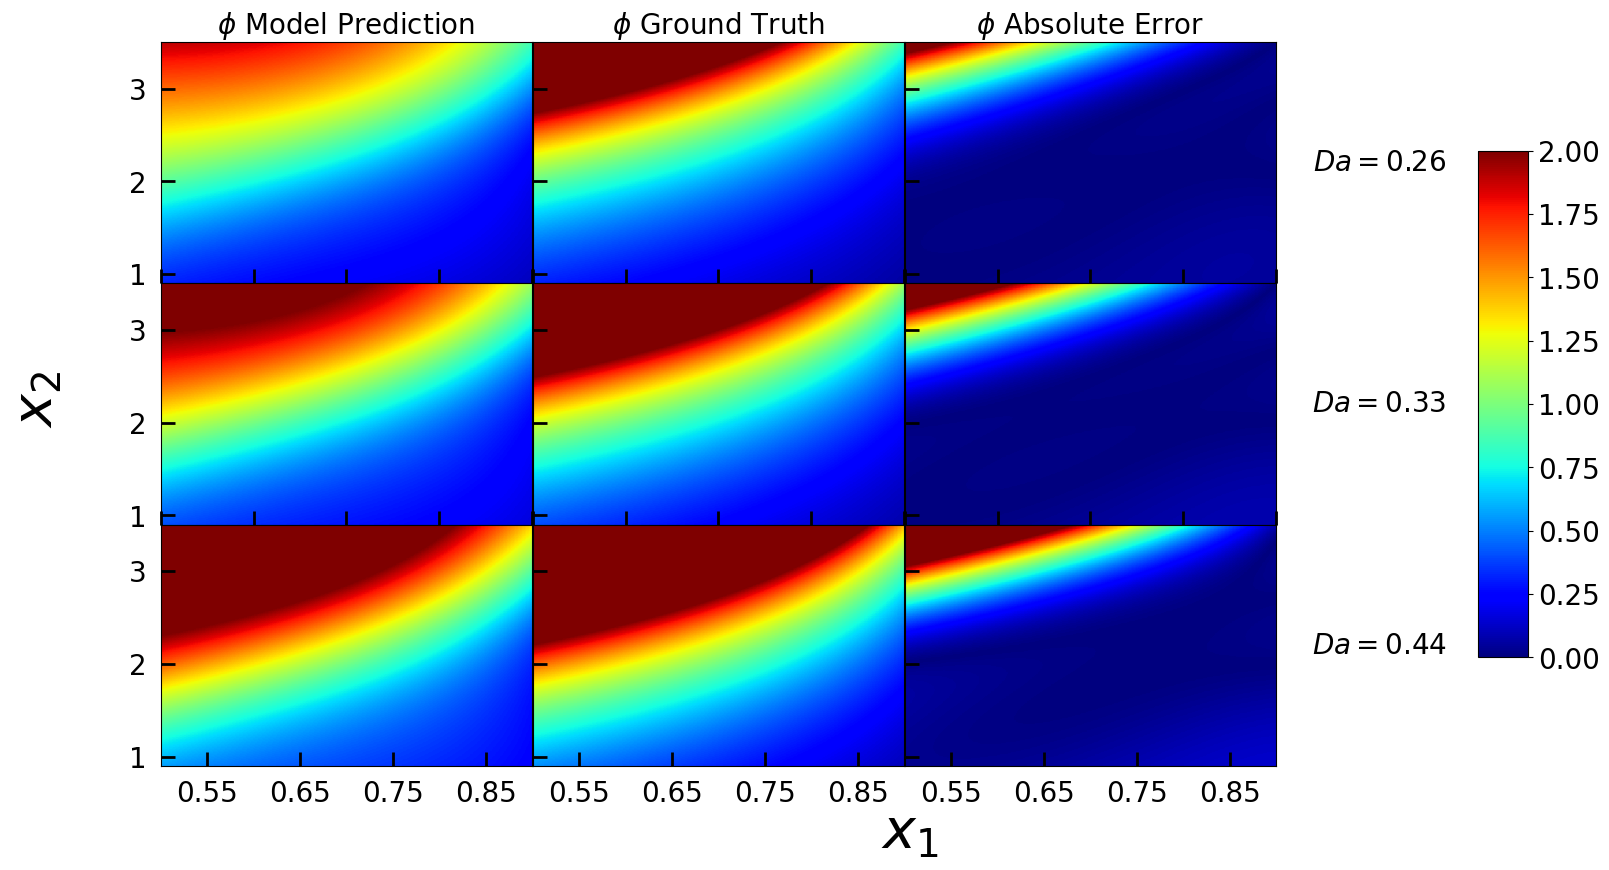

In [166]:
fig, axes = plt.subplots(figsize=(20, 9.4), nrows=Da_arr.size, ncols=3)
for i, Da in enumerate(Da_arr):
    ax = axes[i,0]
    surf = ax.imshow(phi_out_arr[i,:,:], cmap='jet', vmin=0, vmax=2, extent=[min(x1_arr), max(x1_arr), min(x2_arr), max(x2_arr)],origin='lower')
    # ax.set_xlabel(r'$x_1$', fontsize=20)
    # ax.set_ylabel(r'$x_2$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20, pad=10, length=10, width=2, direction='in', labelbottom="off")
    # ax.set_title(r'$\phi$ Model Prediction', fontsize=20)
    # ax.set_title(r'$Da = $' + str(Da), fontsize=20)
    if i<2:
        ax.set_xticklabels([])
    else:
        ax.set_xticks(np.round(x1_arr,2)[12::25], fontsize=20, rotation=0, ha='center')
    if i < 1:
        ax.set_title(r'$\phi$ Model Prediction', fontsize=20)
    # ax.set_yticklabels([])
    # ax.set_yticks(np.round(x2_arr,2)[::40], fontsize=5, rotation=0, va='bottom')
    ax.set_aspect(0.1)


    ax = axes[i,1]
    surf = ax.imshow(phi_true_arr[i,:,:], cmap='jet', vmin=0, vmax=2, extent=[min(x1_arr), max(x1_arr), min(x2_arr), max(x2_arr)],origin='lower')
    # ax.set_xlabel(r'$x_1$', fontsize=20)
    # ax.set_ylabel(r'$x_2$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20, pad=10, length=10, width=2, direction='in')
    # ax.set_title(r'$\phi$ Ground Truth', fontsize=20)
    if i<2:
        ax.set_xticklabels([])
    else:
        ax.set_xticks(np.round(x1_arr,2)[12::25], fontsize=20, rotation=0, ha='center')
    ax.set_yticklabels([])
    if i < 1:
        ax.set_title(r'$\phi$ Ground Truth', fontsize=20)
    ax.set_aspect(0.1)

    ax = axes[i,2]
    surf = ax.imshow(phi_error_arr[i,:,:], cmap='jet', vmin=0, vmax=2, extent=[min(x1_arr), max(x1_arr), min(x2_arr), max(x2_arr)],origin='lower')
    # ax.set_xlabel(r'$x_1$', fontsize=20)
    # ax.set_ylabel(r'$x_2$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20, pad=10, length=10, width=2, direction='in')
    # ax.set_title(r'$\phi$ Ground Truth', fontsize=20)
    if i<2:
        ax.set_xticklabels([])
    else:
        ax.set_xticks(np.round(x1_arr,2)[12::25], fontsize=20, rotation=0, ha='center')
    if i < 1:
        ax.set_title(r'$\phi$ Absolute Error', fontsize=20)
    ax.set_yticklabels([])
    ax.set_aspect(0.1)
    ax.set_ylabel(r'$Da = $' + str(Da), fontsize=20, rotation=0, ha='right', va='center', labelpad=-400)

    
plt.subplots_adjust(wspace=0, hspace=0)

# fig.subplots_adjust(right=1)
cbar = plt.colorbar(surf, aspect=10, pad=0.13, ax=axes.ravel().tolist(),shrink=0.7)
cbar.ax.tick_params(labelsize=20)
fig.supxlabel(r'$x_1$', fontsize=40)
fig.supylabel(r'$x_2$', fontsize=40, x=0.05)


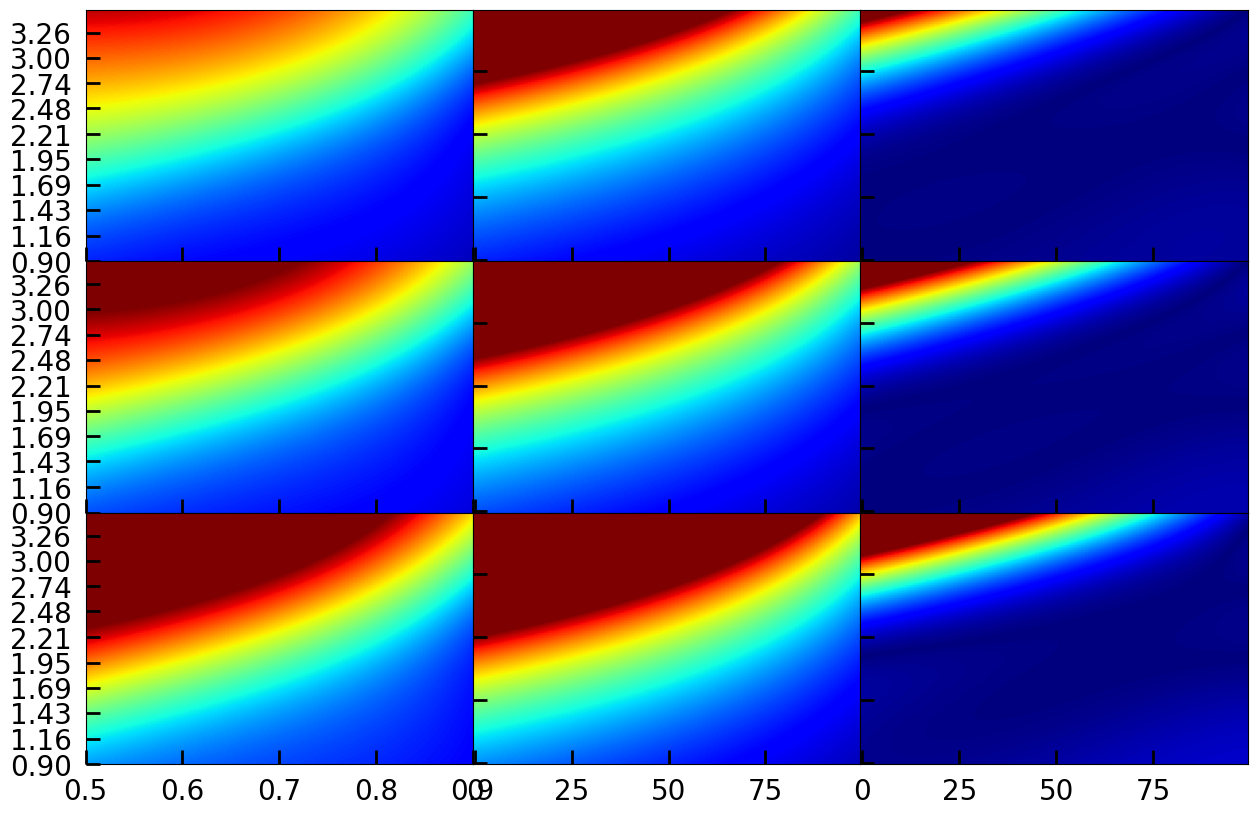

In [87]:
fig, axes = plt.subplots(figsize=(15, 9.8), nrows=Da_arr.size, ncols=3)
for i, Da in enumerate(Da_arr):
    ax = axes[i,0]
    surf = ax.imshow(phi_out_arr[i,:,:], cmap='jet', vmin=0, vmax=2, origin='lower', extent=[min(x1_arr), max(x1_arr), min(x2_arr), max(x2_arr)])
    # ax.set_xlabel(r'$x_1$', fontsize=20)
    # ax.set_ylabel(r'$x_2$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20, pad=10, length=10, width=2, direction='in')
    # ax.set_title(r'$\phi$ Model Prediction', fontsize=20)
    # ax.set_title(r'$Da = $' + str(Da), fontsize=20)
    if i<2:
        ax.set_xticklabels([])
    ax.set_yticks(np.round(x2_arr,2)[::10], fontsize=5)
    # ax.set_yticklabels(np.round(x1_arr,2))
    ax.set_aspect(0.1)


    ax = axes[i,1]
    surf = ax.imshow(phi_true_arr[i,:,:], cmap='jet', vmin=0, vmax=2,origin='lower')
    # ax.set_xlabel(r'$x_1$', fontsize=20)
    # ax.set_ylabel(r'$x_2$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20, pad=10, length=10, width=2, direction='in')
    # ax.set_title(r'$\phi$ Ground Truth', fontsize=20)
    if i<2:
        ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('auto')

    ax = axes[i,2]
    surf = ax.imshow(phi_error_arr[i,:,:], cmap='jet', vmin=0, vmax=2, origin='lower')
    # ax.set_xlabel(r'$x_1$', fontsize=20)
    # ax.set_ylabel(r'$x_2$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20, pad=10, length=10, width=2, direction='in')
    # ax.set_title(r'$\phi$ Ground Truth', fontsize=20)
    if i<2:
        ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('auto')

    
plt.subplots_adjust(wspace=0, hspace=0)


In [83]:
np.round(x1_arr,2)

[array([0.5 , 0.5 , 0.51, 0.51, 0.52, 0.52, 0.52, 0.53, 0.53, 0.54, 0.54,
        0.54, 0.55, 0.55, 0.56, 0.56, 0.56, 0.57, 0.57, 0.58, 0.58, 0.58,
        0.59, 0.59, 0.6 , 0.6 , 0.61, 0.61, 0.61, 0.62, 0.62, 0.63, 0.63,
        0.63, 0.64, 0.64, 0.65, 0.65, 0.65, 0.66, 0.66, 0.67, 0.67, 0.67,
        0.68, 0.68, 0.69, 0.69, 0.69, 0.7 , 0.7 , 0.71, 0.71, 0.71, 0.72,
        0.72, 0.73, 0.73, 0.73, 0.74, 0.74, 0.75, 0.75, 0.75, 0.76, 0.76,
        0.77, 0.77, 0.77, 0.78, 0.78, 0.79, 0.79, 0.79, 0.8 , 0.8 , 0.81,
        0.81, 0.82, 0.82, 0.82, 0.83, 0.83, 0.84, 0.84, 0.84, 0.85, 0.85,
        0.86, 0.86, 0.86, 0.87, 0.87, 0.88, 0.88, 0.88, 0.89, 0.89, 0.9 ,
        0.9 ])]